In [7]:
from fixture.factory.feature.closes import factory_closes_n4

closes_n4 = factory_closes_n4()
closes_n4

Date,now,lag_1,lag_2,lag_3,lag_4
datetime[μs],f64,f64,f64,f64,f64
2000-01-06 00:00:00,-70.985214,83.855866,90.561399,15.006756,8.012821
2000-01-07 00:00:00,32.597451,-70.985214,83.855866,90.561399,15.006756
2000-01-08 00:00:00,-7.89266,32.597451,-70.985214,83.855866,90.561399
2000-01-09 00:00:00,-10.862589,-7.89266,32.597451,-70.985214,83.855866
2000-01-10 00:00:00,62.05388,-10.862589,-7.89266,32.597451,-70.985214
…,…,…,…,…,…
2000-04-05 00:00:00,87.613572,0.0,39.39598,46.159001,64.412461
2000-04-06 00:00:00,71.201004,87.613572,0.0,39.39598,46.159001
2000-04-07 00:00:00,131.809689,71.201004,87.613572,0.0,39.39598


In [8]:
import lightgbm as lgb
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# 特徴量とターゲットの分割（to_pandas()で変換）
X = closes_n4[['lag_1', 'lag_2', 'lag_3', 'lag_4']].to_pandas()
y = closes_n4['now'].to_numpy()  # numpy配列に変換

# 時系列を考慮したデータ分割
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False, random_state=42
)

# LightGBM用データセット作成（labelをnumpy配列で指定）
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# 回帰用パラメータ設定
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'verbose': -1
}

# モデル訓練
model = lgb.train(
    params,
    train_data,
    valid_sets=[test_data],
    num_boost_round=500,
    callbacks=[lgb.early_stopping(20)]
)

# 予測と評価
y_pred = np.asarray(model.predict(X_test))  # numpy配列に明示的に変換
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'Test RMSE: {rmse:.4f}')

Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[60]	valid_0's rmse: 79.3147
Test RMSE: 79.3147


MAE: 60.73
R2 Score: -0.48


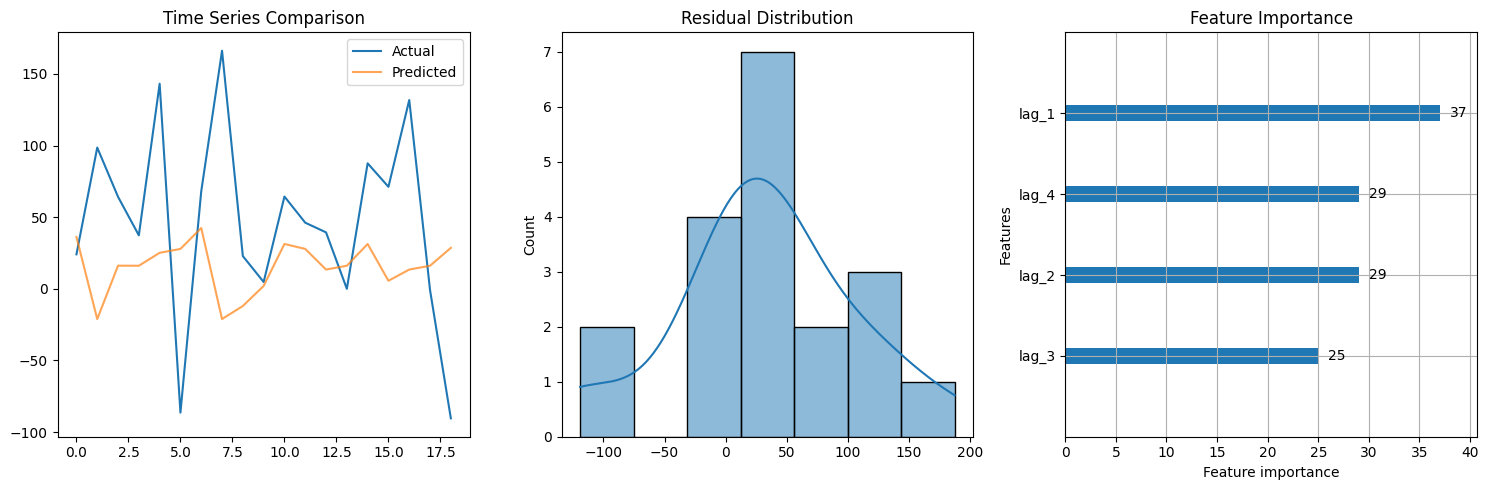

In [10]:
# 追加の評価指標
from sklearn.metrics import mean_absolute_error, r2_score

print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'R2 Score: {r2_score(y_test, y_pred):.2f}')

# 可視化
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 5))

# 1. 実際値 vs 予測値の時系列プロット
plt.subplot(1, 3, 1)
plt.plot(y_test, label='Actual')
plt.plot(y_pred, label='Predicted', alpha=0.7)
plt.title('Time Series Comparison')
plt.legend()

# 2. 残差プロット
plt.subplot(1, 3, 2)
sns.histplot(y_test - y_pred, kde=True)
plt.title('Residual Distribution')

# 3. 特徴量重要度
plt.subplot(1, 3, 3)
lgb.plot_importance(model, max_num_features=10, ax=plt.gca())
plt.title('Feature Importance')

plt.tight_layout()
plt.show()